In [1]:
import numpy as np
from microlensing import Microlensing
from utils import ParamRange, orderOfMagnitude
from consts import *

In [2]:
event_url = "https://www.astrouw.edu.pl/ogle/ogle4/ews/2019/blg-0035"
ms_event = Microlensing(event_url)

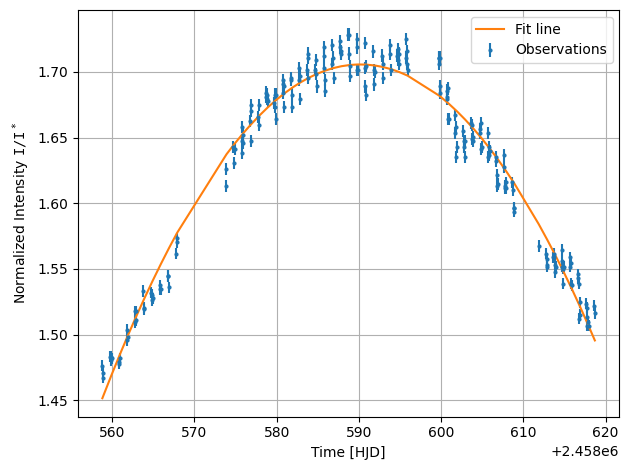

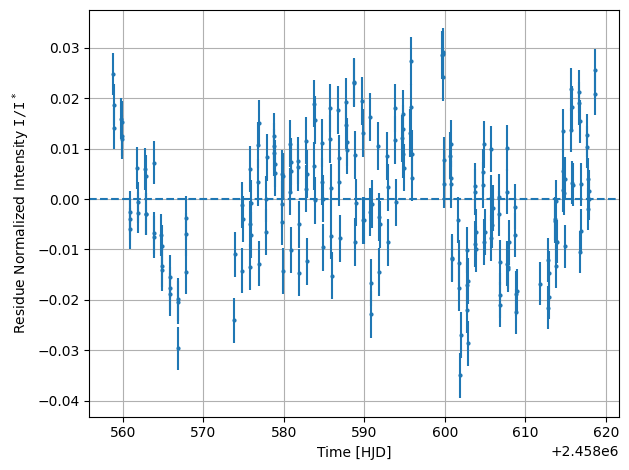

Chi: 8.232299366155976

nsigma with ogle params:
t0_ogle: 2458590.330±0.026
t0_par: 2458590.17±0.18
nsigma: 0.9011629893998434

umin_ogle: 0.68±0.00
umin_par: 0.6847±0.0014
nsigma: 4.174290988597695


{'t0': t0_par: 2458590.17±0.18,
 'Imax': Imax_par: 1.7056±0.0025,
 'umin': umin_par: 0.6847±0.0014}

In [3]:
# Apply linear parabolic fit for initial param guess
mid_range=ms_event.data["JHD"][np.argmax(ms_event.data[I_VAL])]
range_len=30
ms_event.parabolic_fit(mid_range, range_len)

In [4]:
# Use linear parabolic fit params for initial param guess

u_min_par = ms_event.par_params[U_MIN]
t0_par = ms_event.par_params[T0]
std_range = 10

u_min_range = ParamRange(U_MIN, u_min_par.value - u_min_par.lower_error*std_range, u_min_par.value + u_min_par.upper_error*std_range)
t0_range = ParamRange(T0, t0_par.value - t0_par.lower_error*std_range, t0_par.value + t0_par.upper_error*std_range)

params_range = [u_min_range, t0_range]
fixed_params = {TAU: ms_event.ogle[TAU].value, F_BL: ms_event.ogle[F_BL].value}

1.0733214093015704
1.024970423855848
1.024970423855848
1.0916363711949089


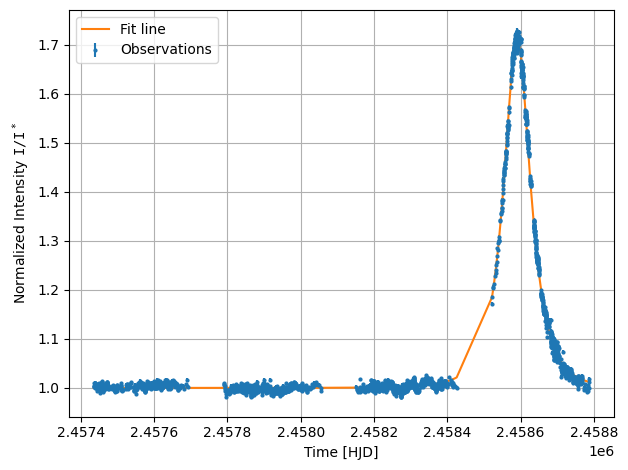

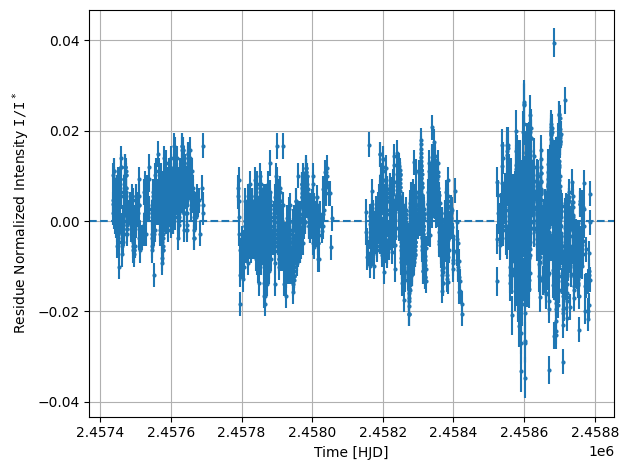

Chi: 19114.137447606936 (Chi Reduced: 6.9556540930156245)

--- nsigma with ogle params ---
umin_ogle: 0.68±0.00
umin_non_linear_2_params: 0.67900[-0.00020,+0.00010]
nsigma: 0.012481182576648835

t0_ogle: 2458590.330±0.026
t0_non_linear_2_params: 2458590.303[-0.018,+0.022]
nsigma: 0.8053505691964208

--- nsigma with parabolic params ---
umin_par: 0.6847±0.0014
umin_non_linear_2_params: 0.67900[-0.00020,+0.00010]
nsigma: 4.160309612752543

t0_par: 2458590.17±0.18
t0_non_linear_2_params: 2458590.303[-0.018,+0.022]
nsigma: 0.7534271385383986



{'umin': umin_non_linear_2_params: 0.67900[-0.00020,+0.00010],
 't0': t0_non_linear_2_params: 2458590.303[-0.018,+0.022]}

In [5]:
ms_event.non_linear_fit(params_range, fixed_params)

t0 vs. umin effect on Goodness of Fit (chi)


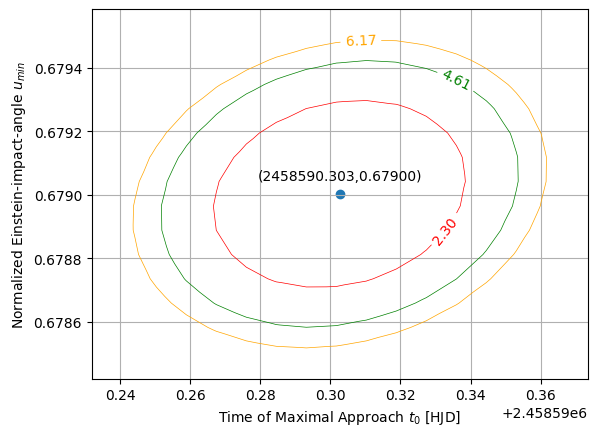

In [6]:

ms_event.non_linear_contours([T0, U_MIN], fixed_params)

In [7]:
for param in params_range:
    #param.n_segments = 5
    order = max(orderOfMagnitude(ms_event.non_linear_params[param.name].upper_error), orderOfMagnitude(ms_event.non_linear_params[param.name].lower_error))
    param.width_res = 10 ** (order-1)
    print(str(param))

param umin: min=0.6710310717143837, max=0.6983888689199058, n_seg=10, width_res=0.0001
param t0: min=2458588.382485034, max=2458591.952411446, n_seg=10, width_res=0.01


In [ ]:
ms_event.non_lin_bootstrap(init_params=params_range, fixed_params=fixed_params, iter=10000)

0 took 1737926743.491201
10 took 2.909621000289917
20 took 2.8053300380706787
30 took 2.919396162033081
40 took 2.734083890914917
50 took 2.728425979614258
60 took 2.8003921508789062
70 took 2.7645509243011475
80 took 2.5226757526397705
90 took 2.4542691707611084
100 took 2.544097900390625
110 took 2.5226831436157227
120 took 2.5871098041534424
130 took 2.7549099922180176
140 took 2.5283961296081543
150 took 2.8143551349639893
160 took 2.550604820251465
170 took 2.6599090099334717
180 took 2.347844123840332
190 took 2.500730037689209
200 took 2.7008988857269287
210 took 2.621145009994507
220 took 2.8198580741882324
230 took 2.635448932647705
240 took 2.629081964492798
250 took 2.5950698852539062
260 took 2.6959011554718018
270 took 2.7033329010009766
280 took 2.571026086807251
290 took 2.6711230278015137
300 took 2.555968999862671
310 took 2.506740093231201
320 took 2.7075977325439453
330 took 2.601597309112549
340 took 2.5563669204711914
350 took 2.6833529472351074
360 took 2.74441719